# EDA de Banking77 para Clustering de FAQs

Este notebook hace un EDA de Banking77 completo y termina con un subconjunto de 8 labels similares para clustering conjunto.

Objetivos:
- Revisar calidad, longitud y distribucion de labels.
- Analizar terminos y representaciones BoW/TF-IDF.
- Definir y exportar un subconjunto de 8 labels funcionalmente cercanos.

In [1]:
from __future__ import annotations

import importlib.util
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Resolver root y cargar DatasetLoader local
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation" / "datasets.py").exists()),
        CANDIDATE_ROOT,
    )

def _load_local_module(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(module)
    return module

datasets_module = _load_local_module("tfg_validation_datasets", ROOT / "validation" / "datasets.py")
DatasetLoader = datasets_module.DatasetLoader

EDA_DIR = ROOT / "validation" / "results" / "banking77_eda"
TABLES_DIR = EDA_DIR / "tables"
FIGURES_DIR = EDA_DIR / "figures"
for p in [EDA_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados EDA: {EDA_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados EDA: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda


/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Carga de Banking77 completo
loader = DatasetLoader()
df = loader.load_banking77(limit=20000).copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

print(df.shape)
print("Labels unicas:", df["label"].nunique())
df.head()

Loading Banking77...
Loaded mteb/banking77 (default) split=train
(9993, 2)
Labels unicas: 77


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [4]:
# Exportar todas las preguntas
questions_path = TABLES_DIR / "banking77_all_questions.csv"
df[["text", "label"]].rename(columns={"text": "question"}).to_csv(
    questions_path, index=False, encoding="utf-8"
)

print(f"Archivo generado: {questions_path}")
df[["text", "label"]].head()

Archivo generado: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_all_questions.csv


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [5]:
# Calidad basica
quality = {
    "n_rows": len(df),
    "n_labels": int(df["label"].nunique()),
    "n_missing_text": int(df["text"].isna().sum()),
    "n_empty_or_blank": int((df["text"].str.strip().str.len() == 0).sum()),
    "n_duplicates_exact": int(df.duplicated(subset=["text"]).sum()),
    "dup_rate": float(df.duplicated(subset=["text"]).mean()),
}

df_quality = pd.DataFrame([quality])
df_quality.to_csv(TABLES_DIR / "quality_summary.csv", index=False)
df_quality

,n_rows,n_labels,n_missing_text,n_empty_or_blank,n_duplicates_exact,dup_rate
0,9993,77,0,0,0,0.0


In [6]:
# Longitud en caracteres y tokens
token_pattern = re.compile(r"\w+", flags=re.UNICODE)
df["char_len"] = df["text"].str.len()
df["tok_len"] = df["text"].apply(lambda t: len(token_pattern.findall(t.lower())))

desc = df[["char_len", "tok_len"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T
desc.to_csv(TABLES_DIR / "length_describe.csv")
desc

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
char_len,9993.0,59.500751,40.873448,13.0,29.0,36.0,47.0,64.0,110.0,152.0,433.0
tok_len,9993.0,12.260082,8.124439,3.0,6.0,8.0,10.0,13.0,22.0,30.0,84.0


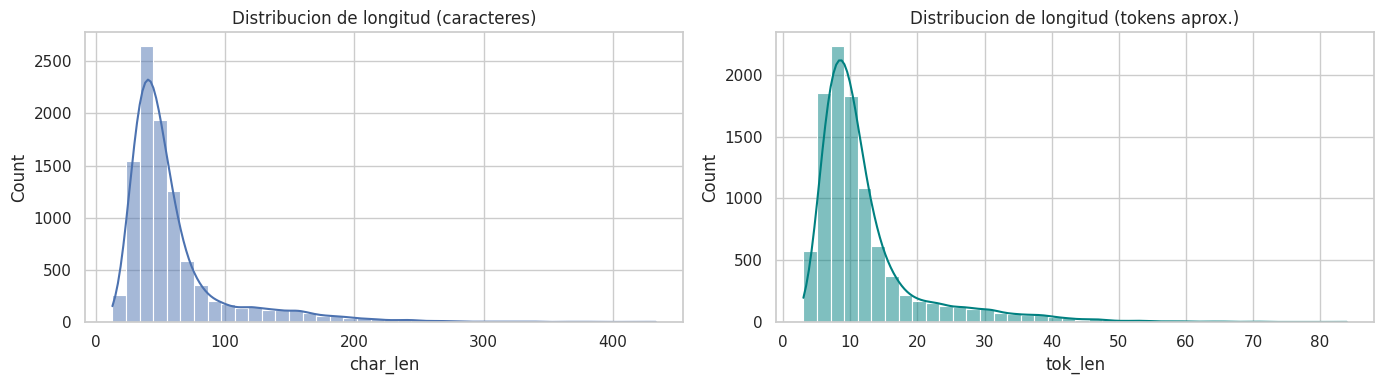

In [7]:
# Distribuciones de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["char_len"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de longitud (caracteres)")

sns.histplot(df["tok_len"], bins=40, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribucion de longitud (tokens aprox.)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "length_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1635369/2617432309.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="count", y="label", ax=ax, palette="viridis")


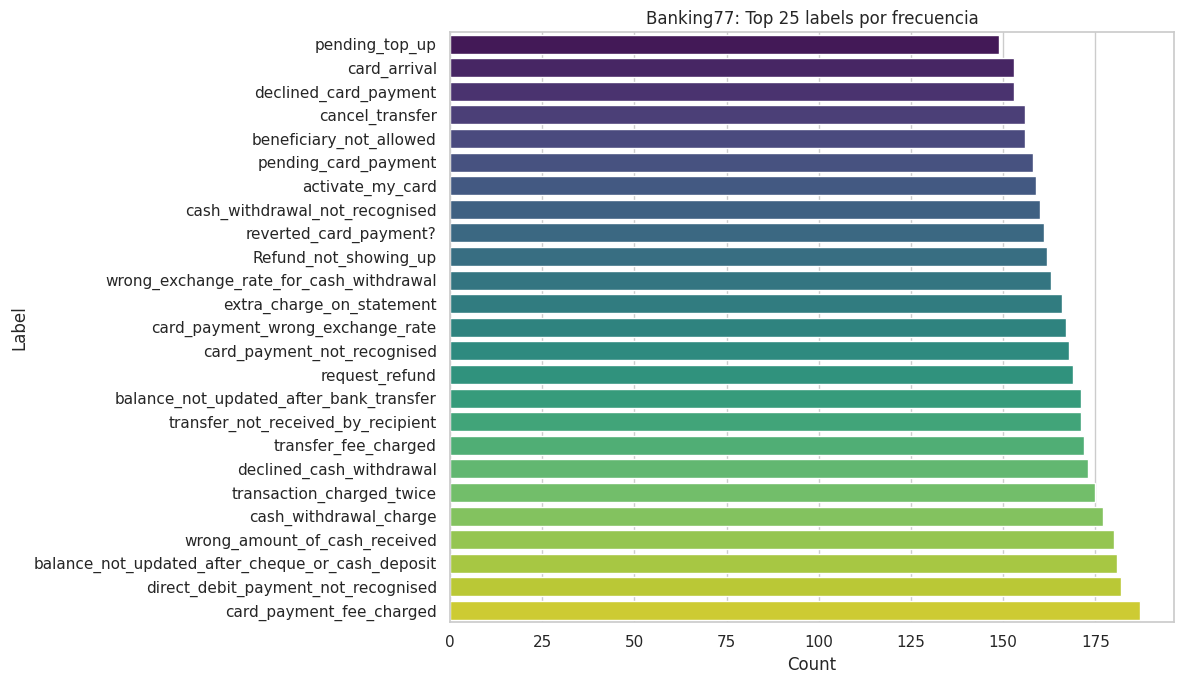

,label,count
0,card_payment_fee_charged,187
1,direct_debit_payment_not_recognised,182
2,balance_not_updated_after_cheque_or_cash_deposit,181
3,wrong_amount_of_cash_received,180
4,cash_withdrawal_charge,177
5,transaction_charged_twice,175
6,declined_cash_withdrawal,173
7,transfer_fee_charged,172
8,transfer_not_received_by_recipient,171
9,balance_not_updated_after_bank_transfer,171


In [8]:
# Distribucion de labels
label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.to_csv(TABLES_DIR / "label_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = label_counts.head(25).sort_values("count", ascending=True)
sns.barplot(data=plot_df, x="count", y="label", ax=ax, palette="viridis")
ax.set_title("Banking77: Top 25 labels por frecuencia")
ax.set_xlabel("Count")
ax.set_ylabel("Label")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "label_distribution_top25.png", dpi=180, bbox_inches="tight")
plt.show()

label_counts.head(10)

In [9]:
# Frecuencias de terminos
texts = df["text"].tolist()

cv_uni = CountVectorizer(stop_words="english", ngram_range=(1, 1), min_df=2, max_df=0.9)
X_uni = cv_uni.fit_transform(texts)
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()
top_uni_idx = np.argsort(freq_uni)[::-1][:30]
df_top_uni = pd.DataFrame({
    "term": np.array(cv_uni.get_feature_names_out())[top_uni_idx],
    "count": freq_uni[top_uni_idx],
})

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=2, max_df=0.9)
X_bi = cv_bi.fit_transform(texts)
freq_bi = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi_idx = np.argsort(freq_bi)[::-1][:30]
df_top_bi = pd.DataFrame({
    "term": np.array(cv_bi.get_feature_names_out())[top_bi_idx],
    "count": freq_bi[top_bi_idx],
})

df_top_uni.to_csv(TABLES_DIR / "top_unigrams.csv", index=False)
df_top_bi.to_csv(TABLES_DIR / "top_bigrams.csv", index=False)

display(df_top_uni.head(15))
display(df_top_bi.head(15))

,term,count
0,card,2681
1,account,1352
2,money,1132
3,transfer,1083
4,payment,751
5,need,697
6,cash,691
7,exchange,549
8,charged,529
9,atm,482


,term,count
0,exchange rate,293
1,new card,226
2,card payment,202
3,virtual card,181
4,cash withdrawal,165
5,money account,148
6,transfer money,118
7,long does,109
8,direct debit,102
9,extra fee,97


In [10]:
# Diagnostico BoW/TF-IDF
bow = CountVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

X_bow = bow.fit_transform(texts)
X_tfidf = tfidf.fit_transform(texts)

def matrix_stats(name: str, X) -> dict:
    n, d = X.shape
    nnz = X.nnz
    sparsity = 1.0 - (nnz / (n * d))
    avg_nnz_row = nnz / n
    return {
        "representation": name,
        "n_samples": n,
        "n_features": d,
        "nnz": int(nnz),
        "sparsity": float(sparsity),
        "avg_nnz_per_doc": float(avg_nnz_row),
    }

df_repr = pd.DataFrame([matrix_stats("bow", X_bow), matrix_stats("tfidf", X_tfidf)])
df_repr.to_csv(TABLES_DIR / "representation_stats.csv", index=False)
df_repr

,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,9993,4000,169008,0.995772,16.912639
1,tfidf,9993,4000,169008,0.995772,16.912639


,k,asw_cosine
0,2,0.014553
1,3,0.018269
2,4,0.019641
3,5,0.022420
4,6,0.023516


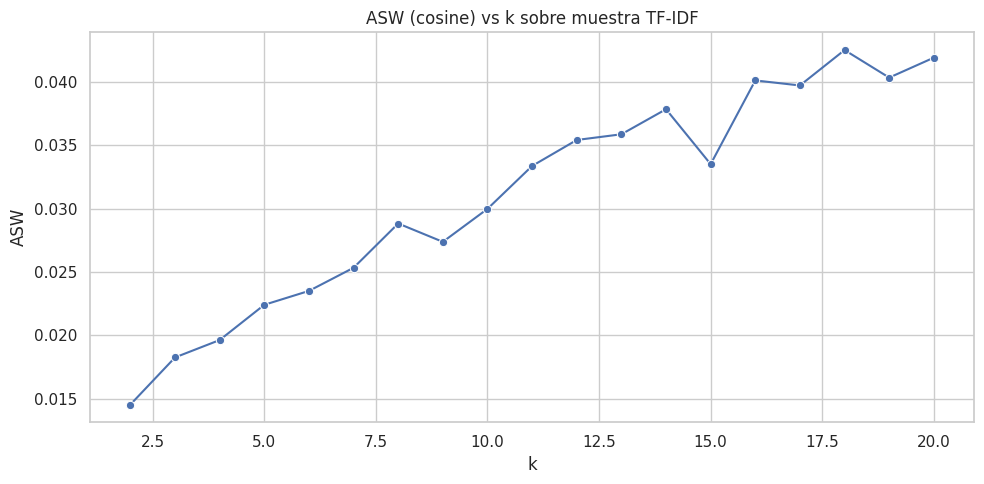

In [11]:
# Heuristica de k con silhouette sobre muestra TF-IDF
sample_n = min(3000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=sample_n, replace=False)
X_sample = X_tfidf[sample_idx]

k_values = list(range(2, 21))
rows = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    asw = silhouette_score(X_sample, labels, metric="cosine")
    rows.append({"k": k, "asw_cosine": float(asw)})

df_k_scan = pd.DataFrame(rows)
df_k_scan.to_csv(TABLES_DIR / "k_scan_tfidf_cosine_sample.csv", index=False)
display(df_k_scan.head())

ax = sns.lineplot(data=df_k_scan, x="k", y="asw_cosine", marker="o")
ax.set_title("ASW (cosine) vs k sobre muestra TF-IDF")
ax.set_xlabel("k")
ax.set_ylabel("ASW")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "k_scan_tfidf_cosine_sample.png", dpi=180, bbox_inches="tight")
plt.show()

In [12]:
# Subconjunto de 8 labels similares (tarjeta + retirada)
SIMILAR_LABELS = [
    "beneficiary_not_allowed",
    "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised",
    "card_linking",
    "card_arrival",
    "card_delivery_estimate",
    "card_not_working",
    "card_payment_not_recognised",
]

available = set(df["label"].unique())
missing = [lbl for lbl in SIMILAR_LABELS if lbl not in available]
if missing:
    raise ValueError(f"Labels no encontradas en Banking77: {missing}")

df_subset = df[df["label"].isin(SIMILAR_LABELS)].copy().reset_index(drop=True)
subset_counts = df_subset["label"].value_counts().rename_axis("label").reset_index(name="count")

subset_path = TABLES_DIR / "banking77_similar8_subset.csv"
subset_counts_path = TABLES_DIR / "banking77_similar8_subset_label_distribution.csv"
df_subset.to_csv(subset_path, index=False, encoding="utf-8")
subset_counts.to_csv(subset_counts_path, index=False, encoding="utf-8")

print(f"Subset exportado en: {subset_path}")
print(f"Distribucion de labels en: {subset_counts_path}")
print(f"Filas en subset: {len(df_subset)} | labels: {df_subset['label'].nunique()}")
subset_counts

Subset exportado en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_subset.csv
Distribucion de labels en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_subset_label_distribution.csv
Filas en subset: 1176 | labels: 8


,label,count
0,cash_withdrawal_charge,177
1,card_payment_not_recognised,168
2,cash_withdrawal_not_recognised,160
3,beneficiary_not_allowed,156
4,card_arrival,153
5,card_linking,139
6,card_delivery_estimate,112
7,card_not_working,111


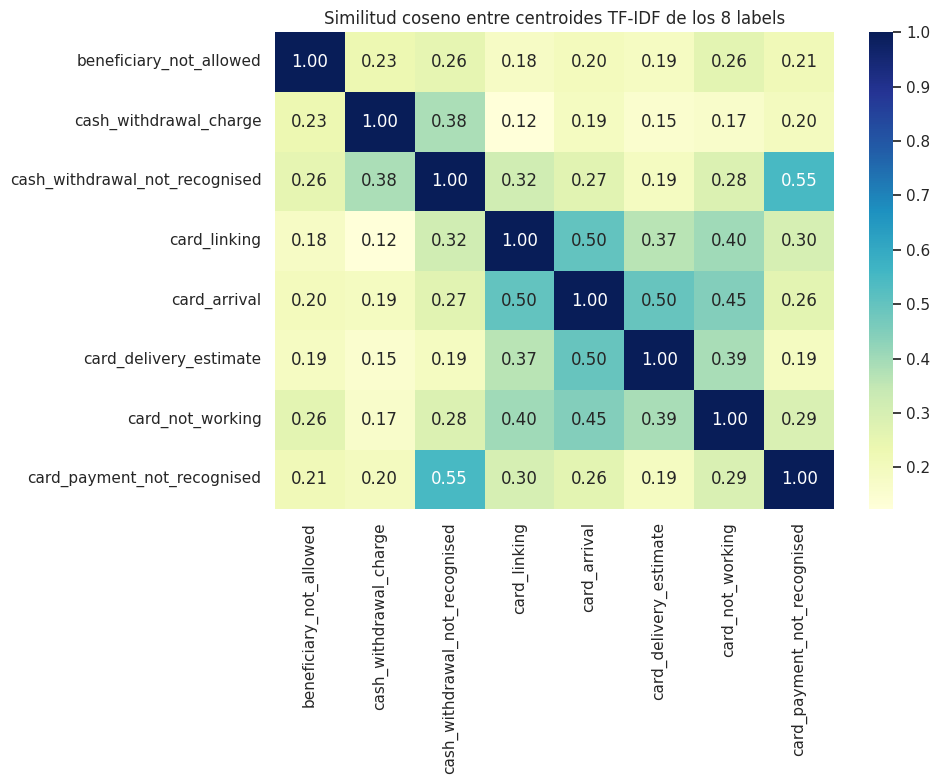

In [13]:
# Similitud entre centroides TF-IDF de los 8 labels
from sklearn.metrics.pairwise import cosine_similarity

subset_texts = df_subset["text"].tolist()
subset_tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_subset = subset_tfidf.fit_transform(subset_texts)

label_to_rows = {}
for lbl in SIMILAR_LABELS:
    idx = np.where(df_subset["label"].values == lbl)[0]
    label_to_rows[lbl] = idx

centroids = []
for lbl in SIMILAR_LABELS:
    rows = label_to_rows[lbl]
    centroids.append(np.asarray(X_subset[rows].mean(axis=0)).ravel())

centroids = np.vstack(centroids)
sim = cosine_similarity(centroids)
sim_df = pd.DataFrame(sim, index=SIMILAR_LABELS, columns=SIMILAR_LABELS)
sim_df.to_csv(TABLES_DIR / "banking77_similar8_centroid_cosine_similarity.csv", encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Similitud coseno entre centroides TF-IDF de los 8 labels")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "banking77_similar8_centroid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## Resultado principal del EDA

Archivo listo para el experimento de clustering:
- validation/results/banking77_eda/tables/banking77_similar8_subset.csv

Este subconjunto contiene todas las preguntas de 8 labels relacionados con incidencias de tarjeta y retirada de efectivo.